In [4]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [5]:
from src.features.preprocessing import (
    clean_columns,
    apply_genre_grouping,
    remove_unwanted_classes,
    split_features_target
)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
from sklearn.cluster import KMeans,AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/raw/SpotifyFeatures.csv")
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [6]:
df = clean_columns(df)
df = apply_genre_grouping(df)
df = remove_unwanted_classes(df)

X, y = split_features_target(df)

print(X.shape)
print(y.shape)
print(y.value_counts())

(222925, 14)
(222925,)
genre_grouped
rock            28078
soundtrack      26388
hiphop          18527
jazz_blues      18464
pop             18087
rnb             18081
folk_country    17963
reggae          17645
classical       17536
kids            14756
electronic       9377
world            9096
latin            8927
Name: count, dtype: int64


In [8]:
df.describe(include='all')

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
count,232725,232725,232724,232725,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725,232725.000000,232725.000000,232725,232725.000000,232725.000000,232725,232725.000000
unique,27,14564,148614,176774,NaN,NaN,NaN,NaN,NaN,NaN,12,NaN,NaN,2,NaN,NaN,5,NaN
top,Comedy,Giuseppe Verdi,Home,3R73Y7X53MIQZWnKloWq5i,NaN,NaN,NaN,NaN,NaN,NaN,C,NaN,NaN,Major,NaN,NaN,4/4,NaN
freq,9681,1394,100,8,NaN,NaN,NaN,NaN,NaN,NaN,27583,NaN,NaN,151744,NaN,NaN,200760,NaN
mean,NaN,NaN,NaN,NaN,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,NaN,0.215009,-9.569885,NaN,0.120765,117.666585,NaN,0.454917
std,NaN,NaN,NaN,NaN,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,NaN,0.198273,5.998204,NaN,0.185518,30.898907,NaN,0.260065
min,NaN,NaN,NaN,NaN,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,NaN,0.009670,-52.457000,NaN,0.022200,30.379000,NaN,0.000000
25%,NaN,NaN,NaN,NaN,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,NaN,0.097400,-11.771000,NaN,0.036700,92.959000,NaN,0.237000
50%,NaN,NaN,NaN,NaN,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,NaN,0.128000,-7.762000,NaN,0.050100,115.778000,NaN,0.444000
75%,NaN,NaN,NaN,NaN,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,NaN,0.264000,-5.501000,NaN,0.105000,139.054000,NaN,0.660000


In [9]:
df.isna().sum()

genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df=df.drop(columns=['artist_name','track_name','track_id'])
df.columns

Index(['genre', 'popularity', 'acousticness', 'danceability', 'duration_ms',
       'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='object')

In [12]:
obj_dis_col=['genre','key','mode','time_signature']
for col in obj_dis_col:
    display(df[col].value_counts().reset_index())
    print('*'*50)

,genre,count
0,Comedy,9681
1,Soundtrack,9646
2,Indie,9543
3,Jazz,9441
4,Pop,9386
5,Electronic,9377
6,Children’s Music,9353
7,Folk,9299
8,Hip-Hop,9295
9,Rock,9272


**************************************************


,key,count
0,C,27583
1,G,26390
2,D,24077
3,C#,23201
4,A,22671
5,F,20279
6,B,17661
7,E,17390
8,A#,15526
9,F#,15222


**************************************************


,mode,count
0,Major,151744
1,Minor,80981


**************************************************


,time_signature,count
0,4/4,200760
1,3/4,24111
2,5/4,5238
3,1/4,2608
4,0/4,8


**************************************************


In [13]:

df['genre'] = df['genre'].str.replace('Children’s Music', "Children's Music")

print("Géneros únicos después de la limpieza:", df['genre'].nunique())

Géneros únicos después de la limpieza: 26


### Analisis Univariado

<Figure size 800x500 with 0 Axes>

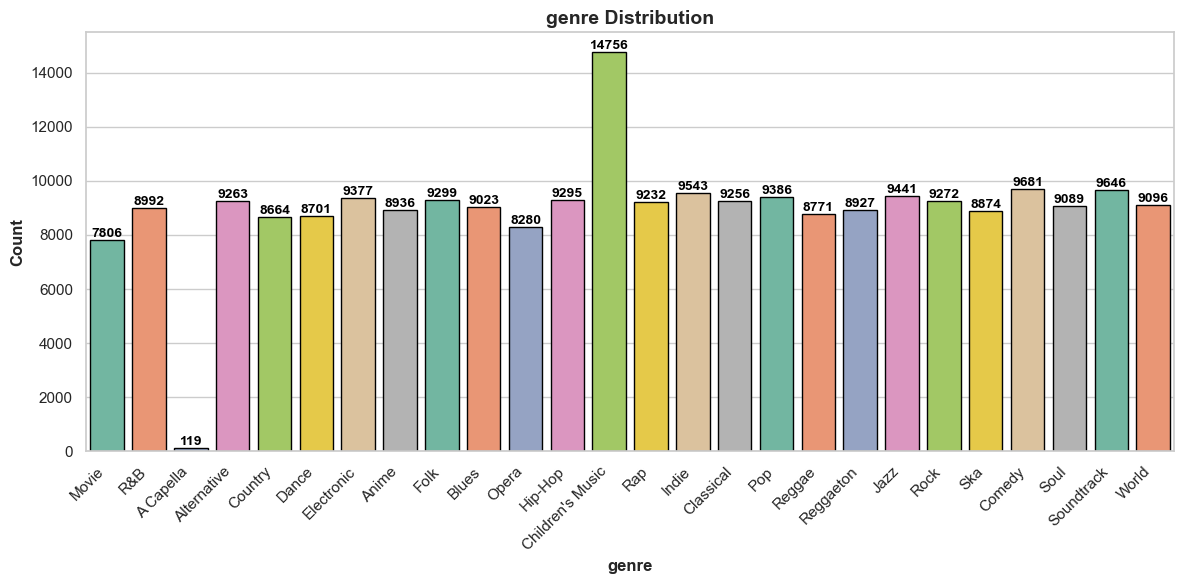

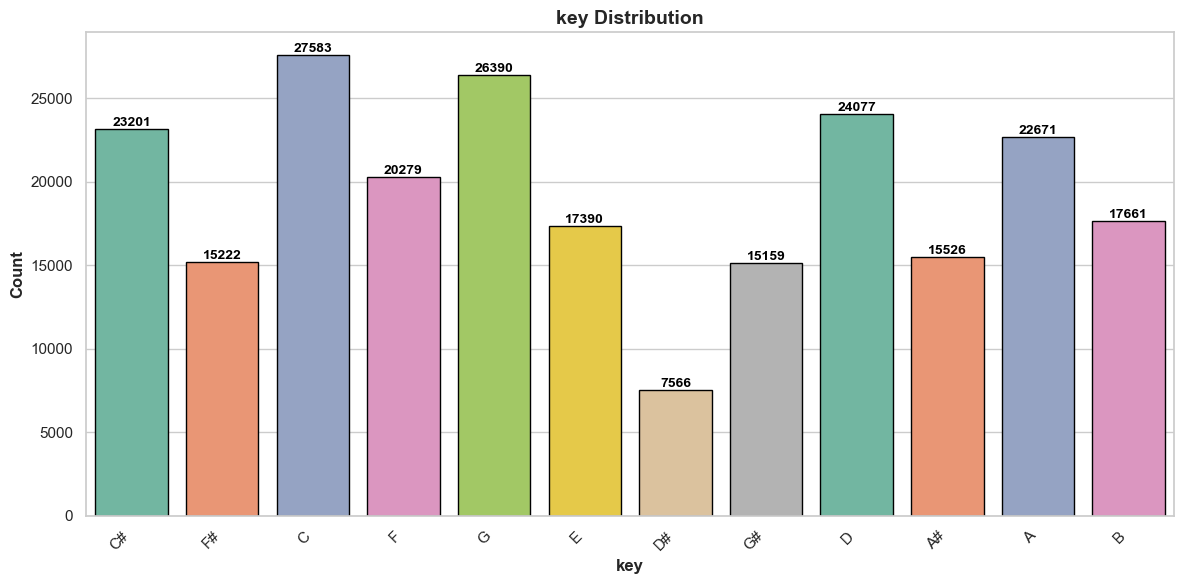

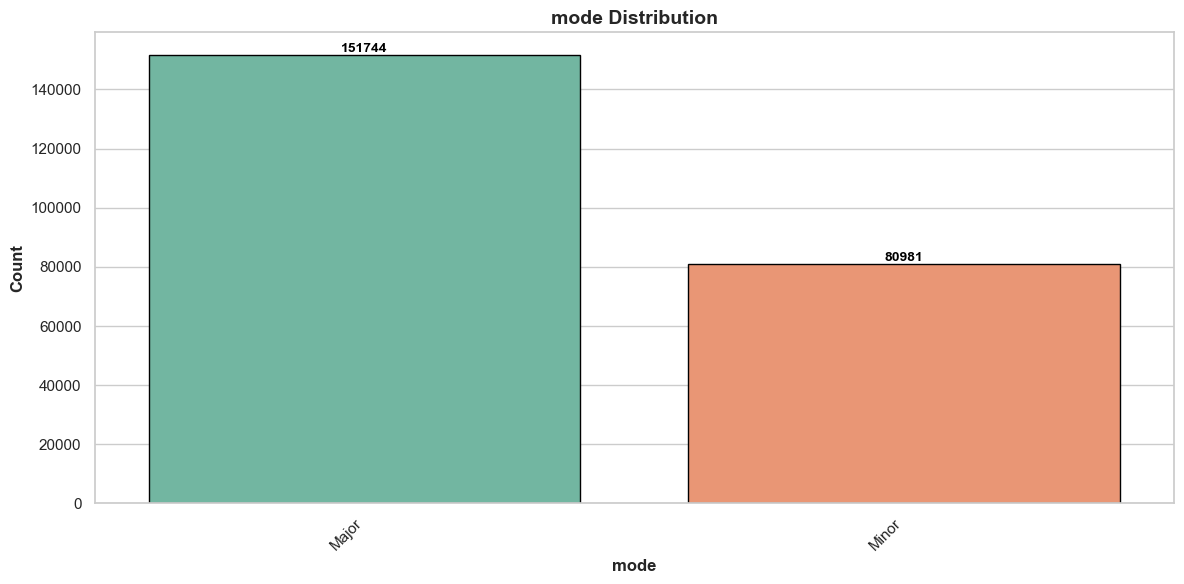

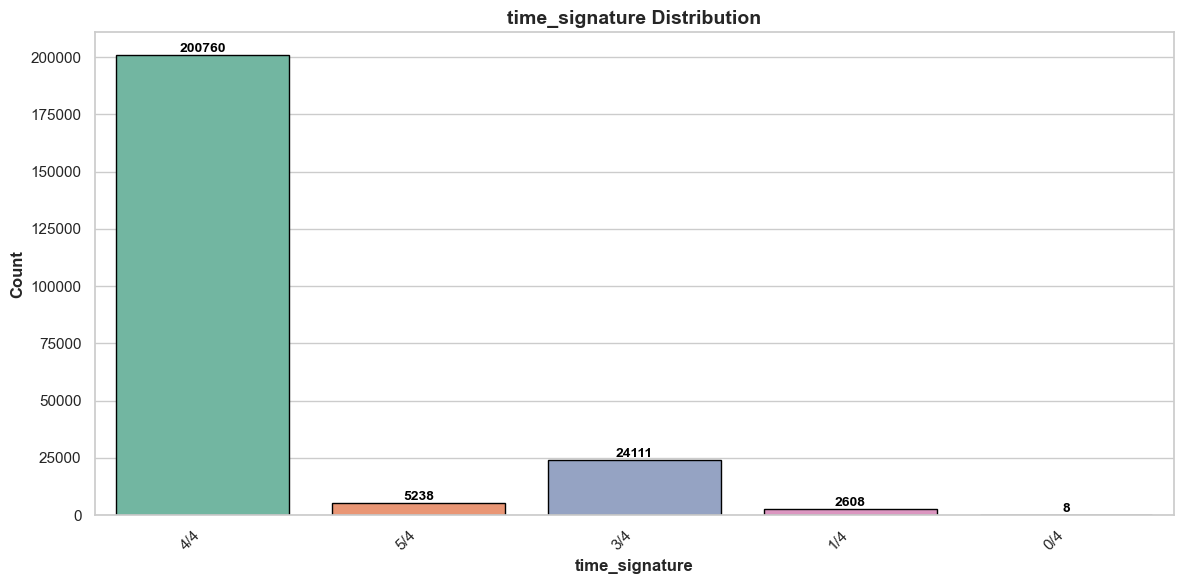

In [14]:
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(8, 5))

for col in obj_dis_col:
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(data=df, x=col, palette="Set2", edgecolor='black')
    
    plt.xlabel(col, fontsize=12, weight='bold')
    plt.ylabel("Count", fontsize=12, weight='bold')
    plt.title(f"{col} Distribution", fontsize=14, weight='bold')
    
    plt.xticks(rotation=45, ha='right')
    
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=10, color='black', weight='bold')
    
    plt.tight_layout()
    plt.show()

## Análisis breve
La mayoría de las canciones están escritas en tonalidades simples como Do (C), Sol (G) y Re (D), lo que refleja la preferencia de los artistas por tonalidades fáciles y ampliamente accesibles.

El mode mayor predomina con casi el doble que el modo menor, lo que muestra que el mercado en general se inclina hacia ambientes musicales más brillantes y alegres.

Géneros como Música Infantil están separadas en dos variables diferentes lo que puede ser una inconcistencia en los datos,

Acapella es un género significativamente menor escuchado comparado con el resto de generos.

También podemos destacar que hay valores con un beats de 0, lo cual no tiene sentido ya que no podemos tener una canción sin ningún beat.

<Figure size 800x500 with 0 Axes>

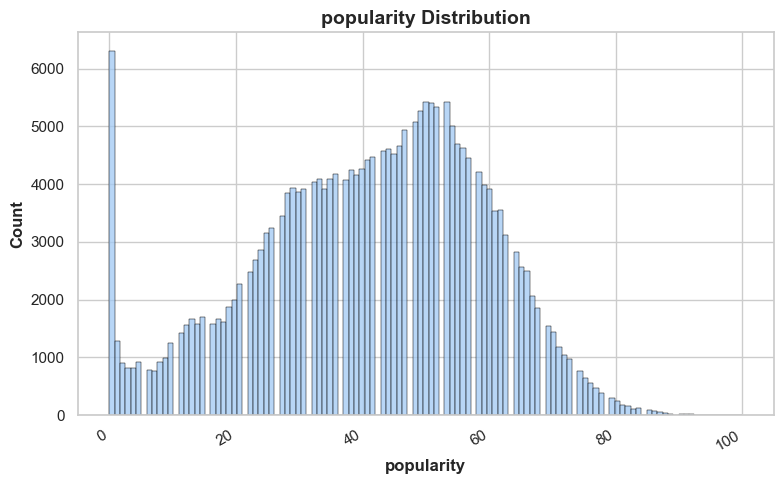

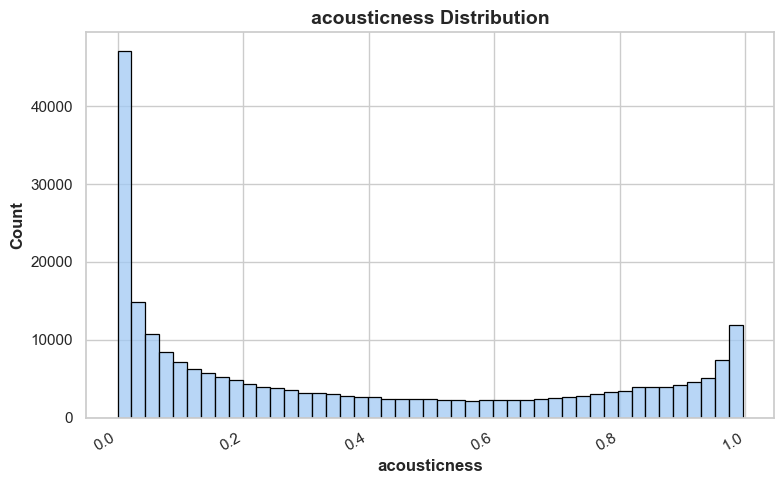

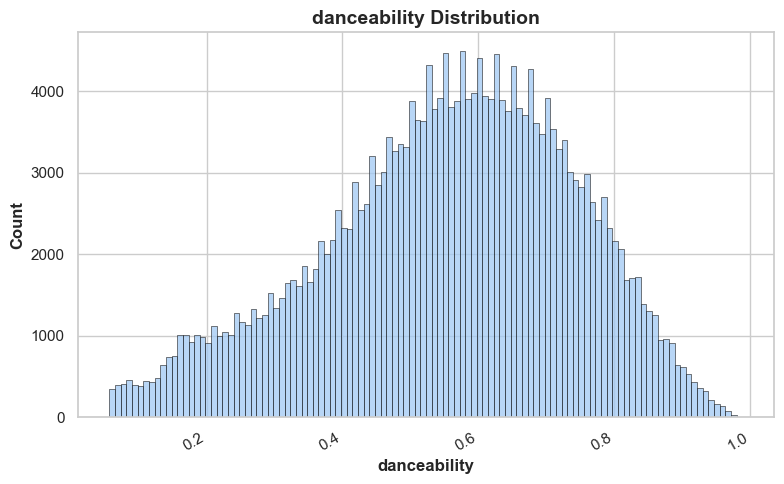

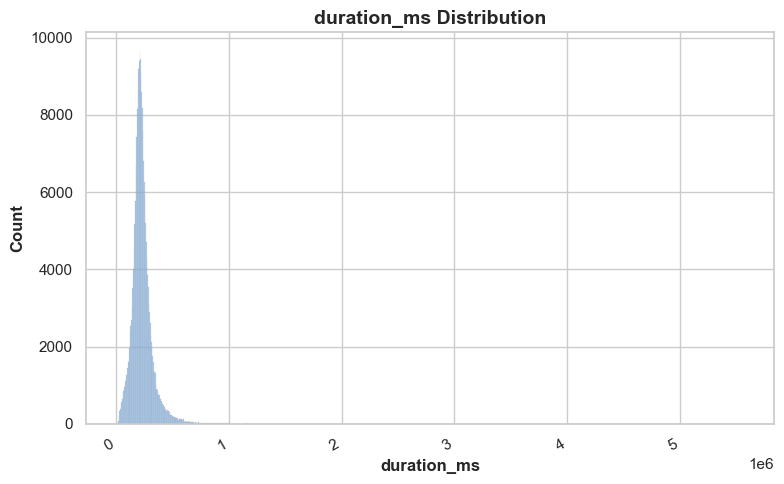

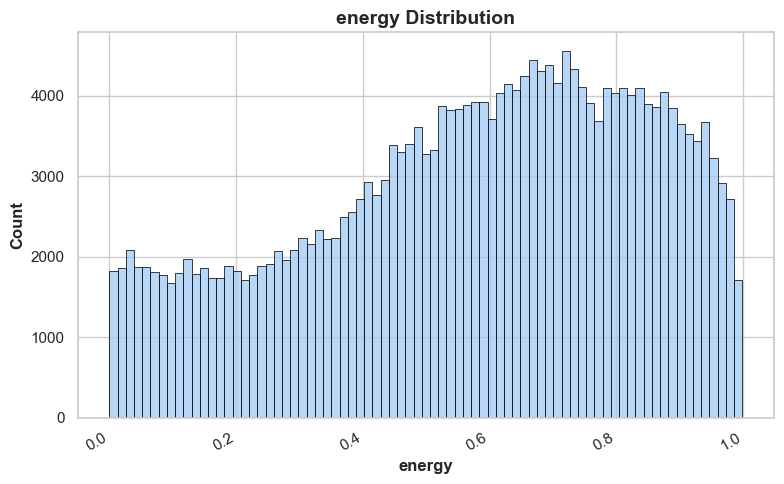

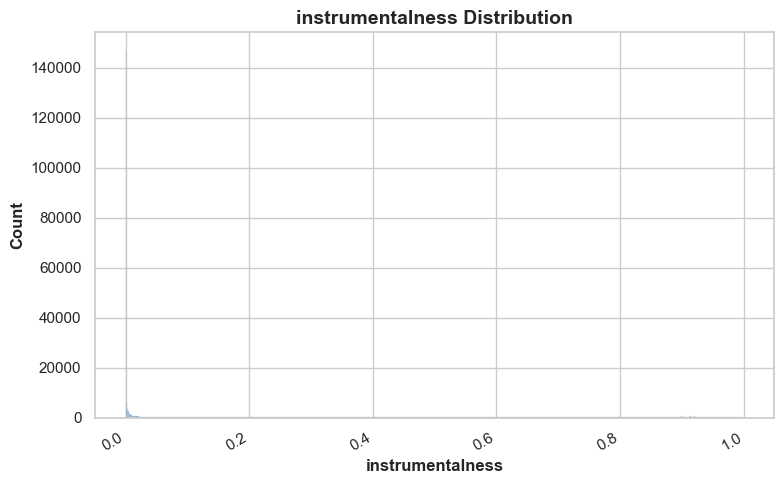

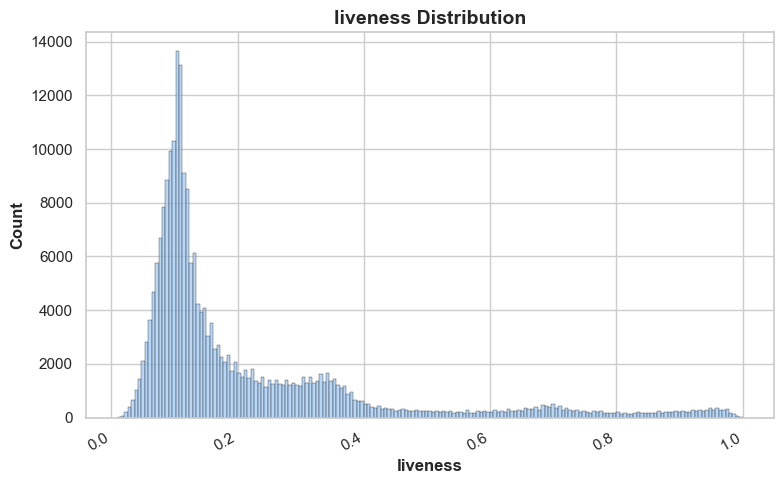

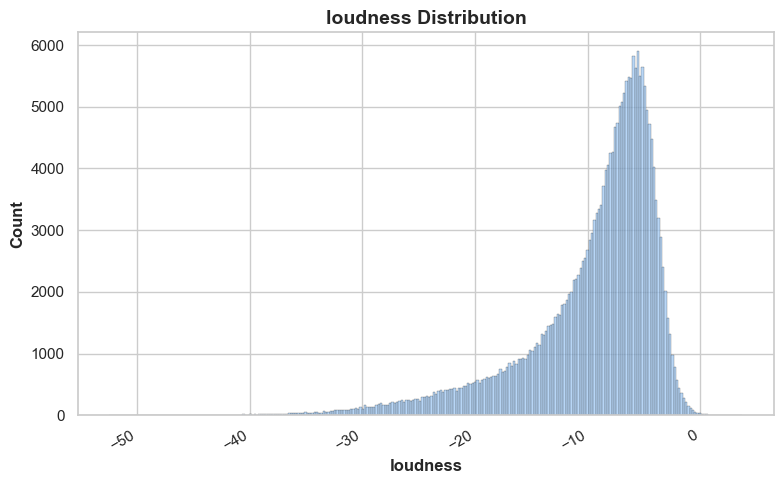

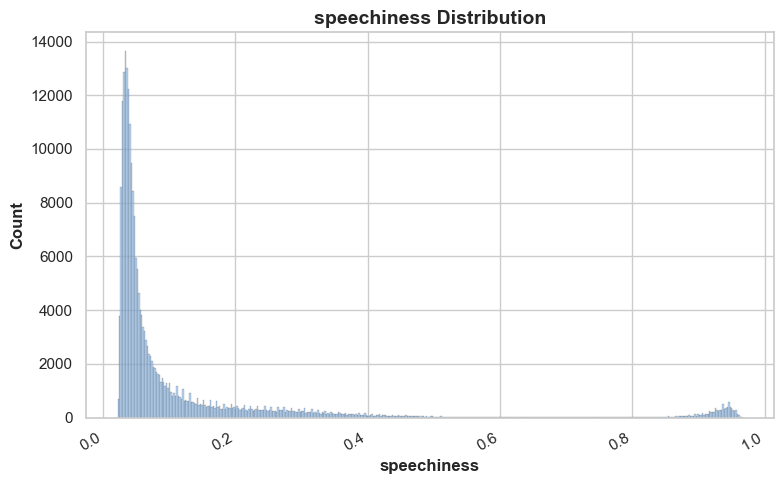

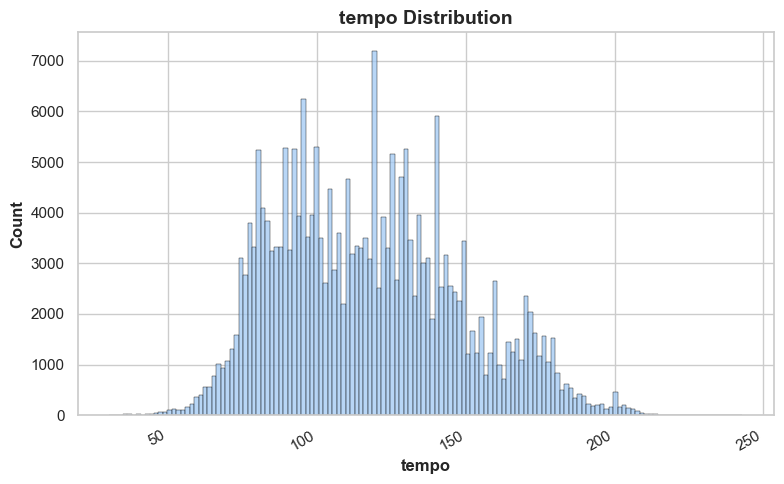

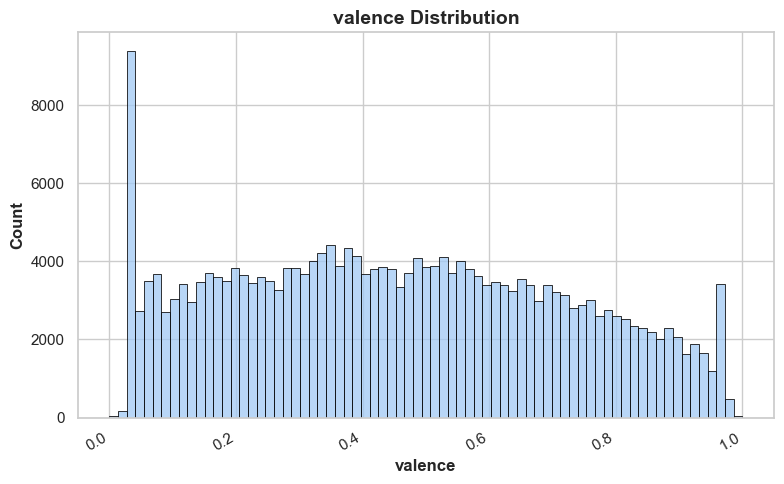

In [15]:
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(8, 5))

for col in df.columns:
    if col not in obj_dis_col:
        plt.figure(figsize=(8, 5))
        ax = sns.histplot(data=df, x=col, palette="Set2", edgecolor='black')
        
        plt.xlabel(col, fontsize=12, weight='bold')
        plt.ylabel("Count", fontsize=12, weight='bold')
        plt.title(f"{col} Distribution", fontsize=14, weight='bold')
        
        plt.xticks(rotation=30, ha='right')
        
        plt.tight_layout()
        plt.show()

### Analisis Bivariado

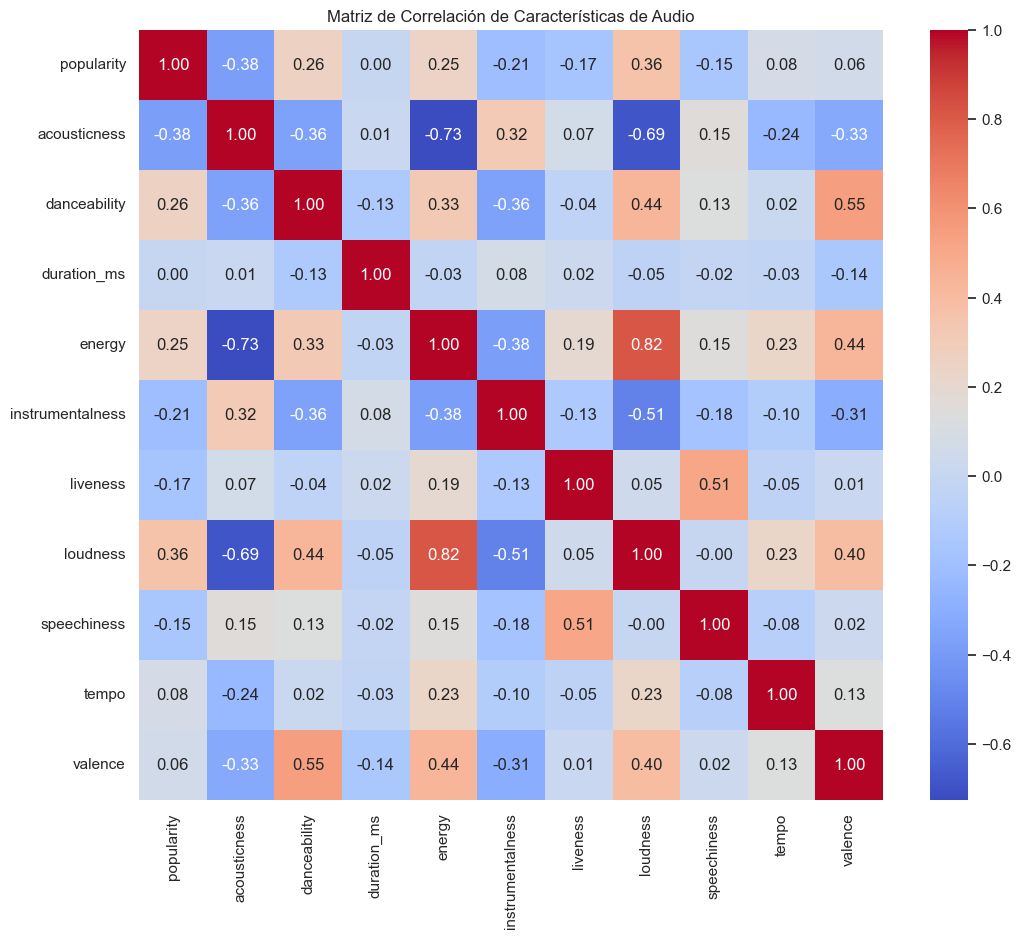

In [19]:
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlación de Características de Audio')
plt.show()

Loudness vs Energy tiene una correlación alta ya que canciones con volumenes mas altos suelen ser más energicas.

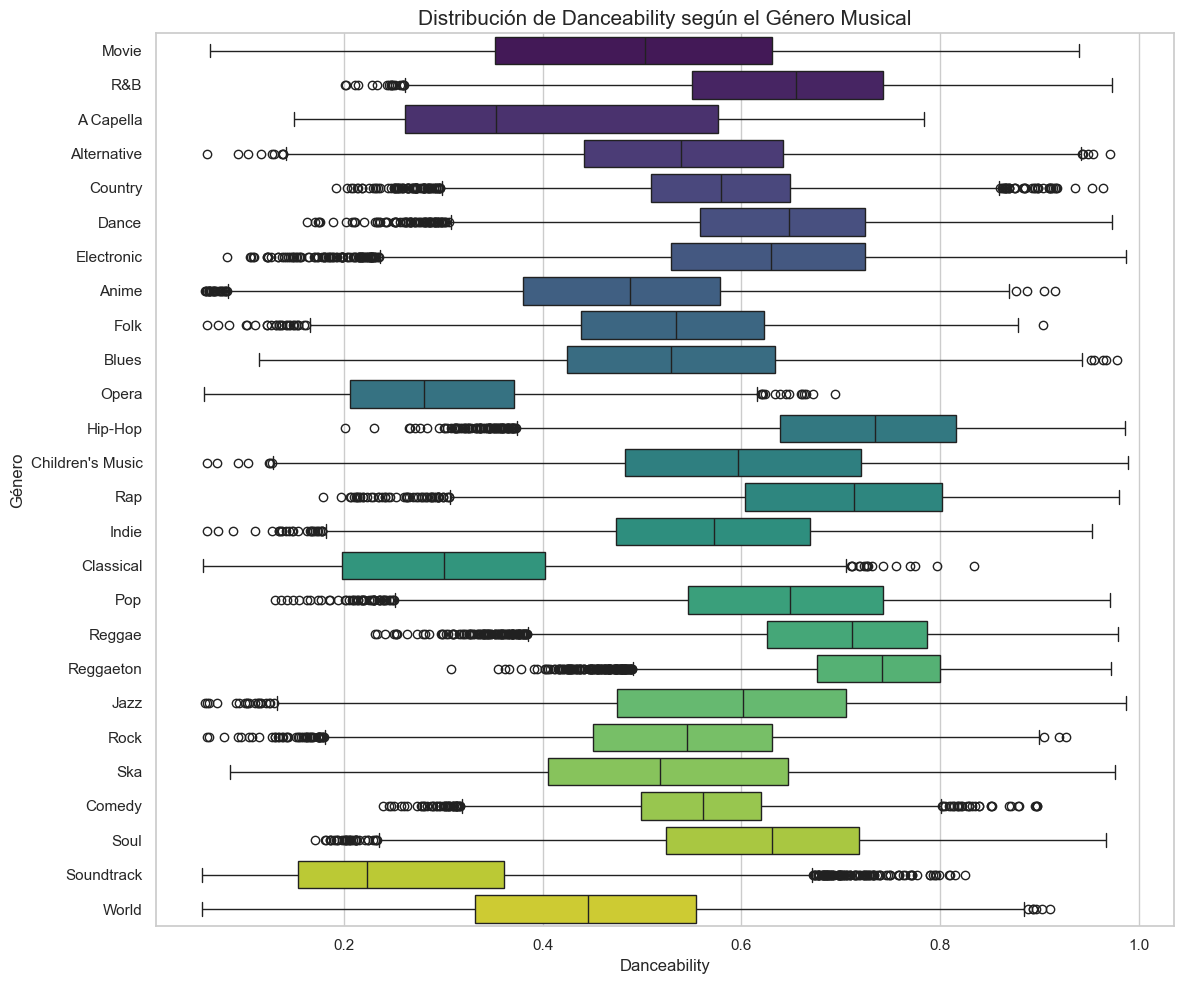

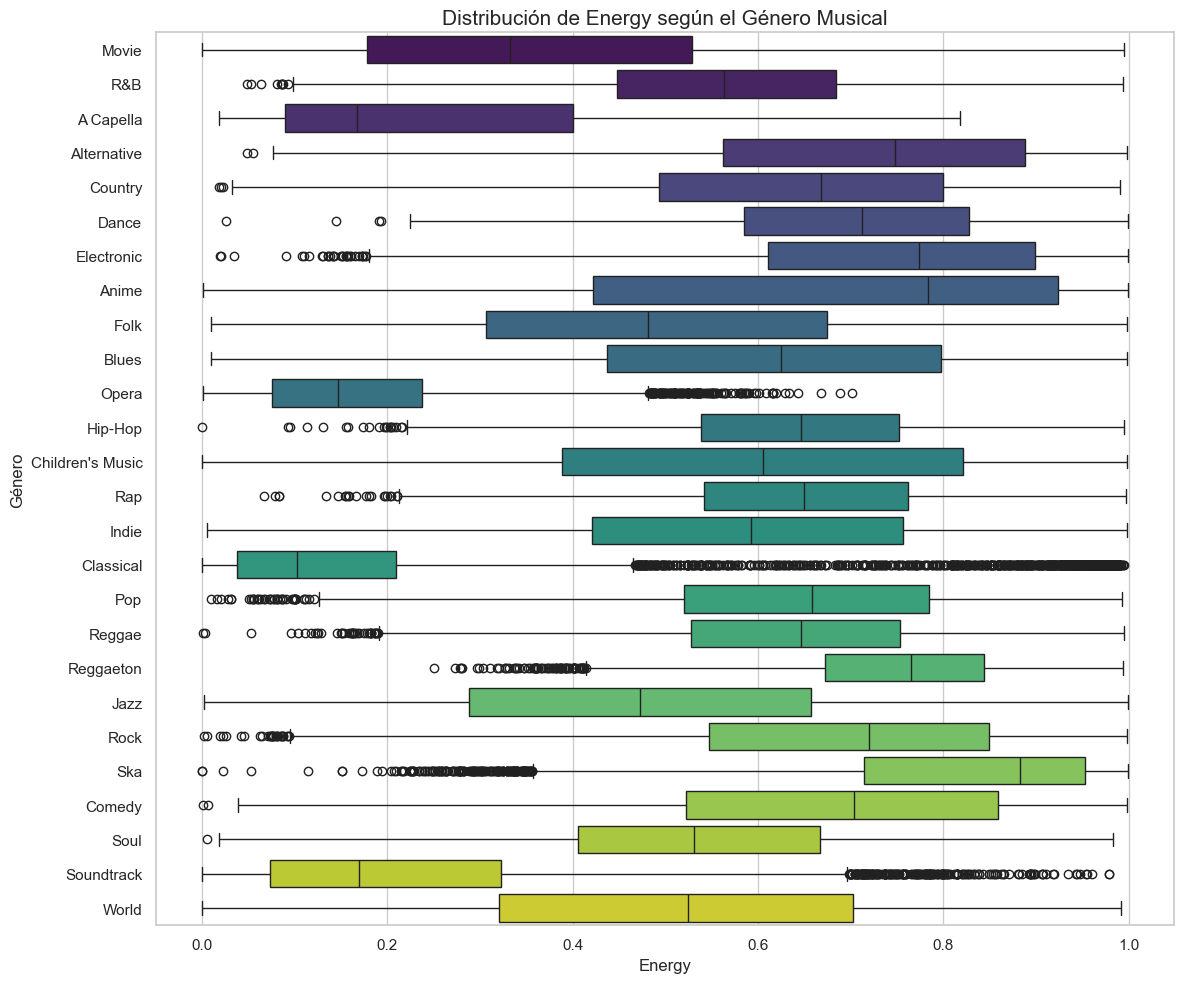

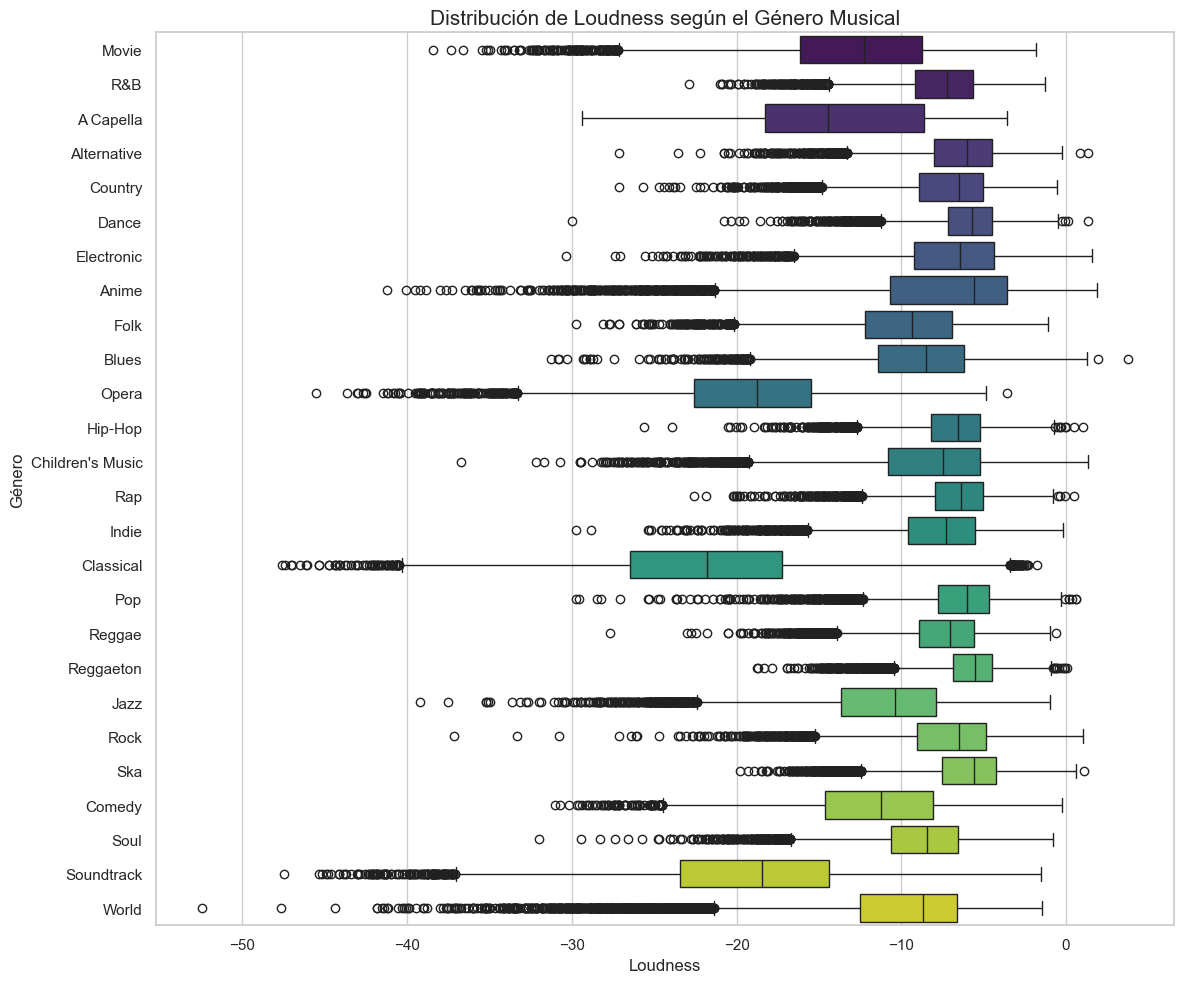

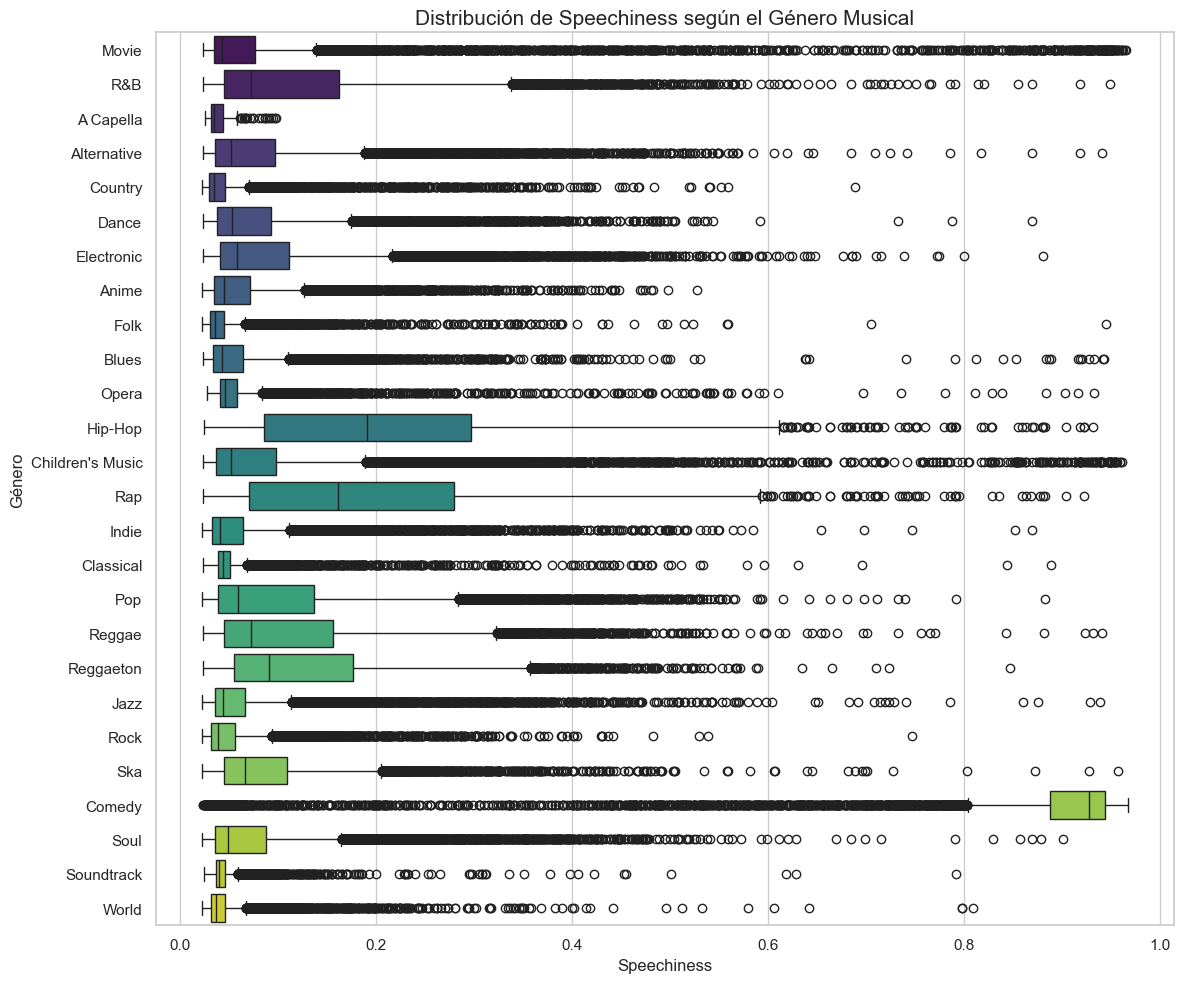

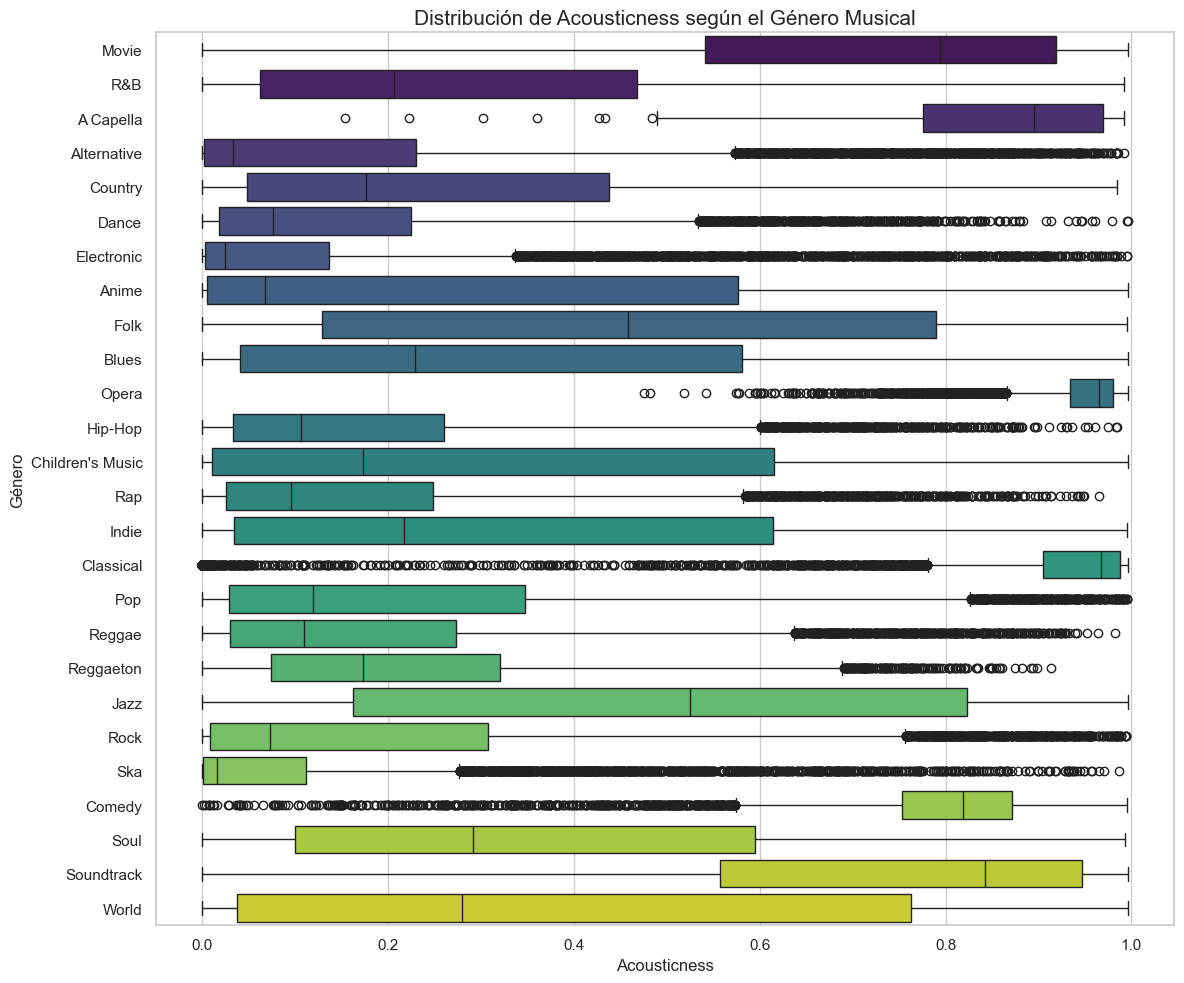

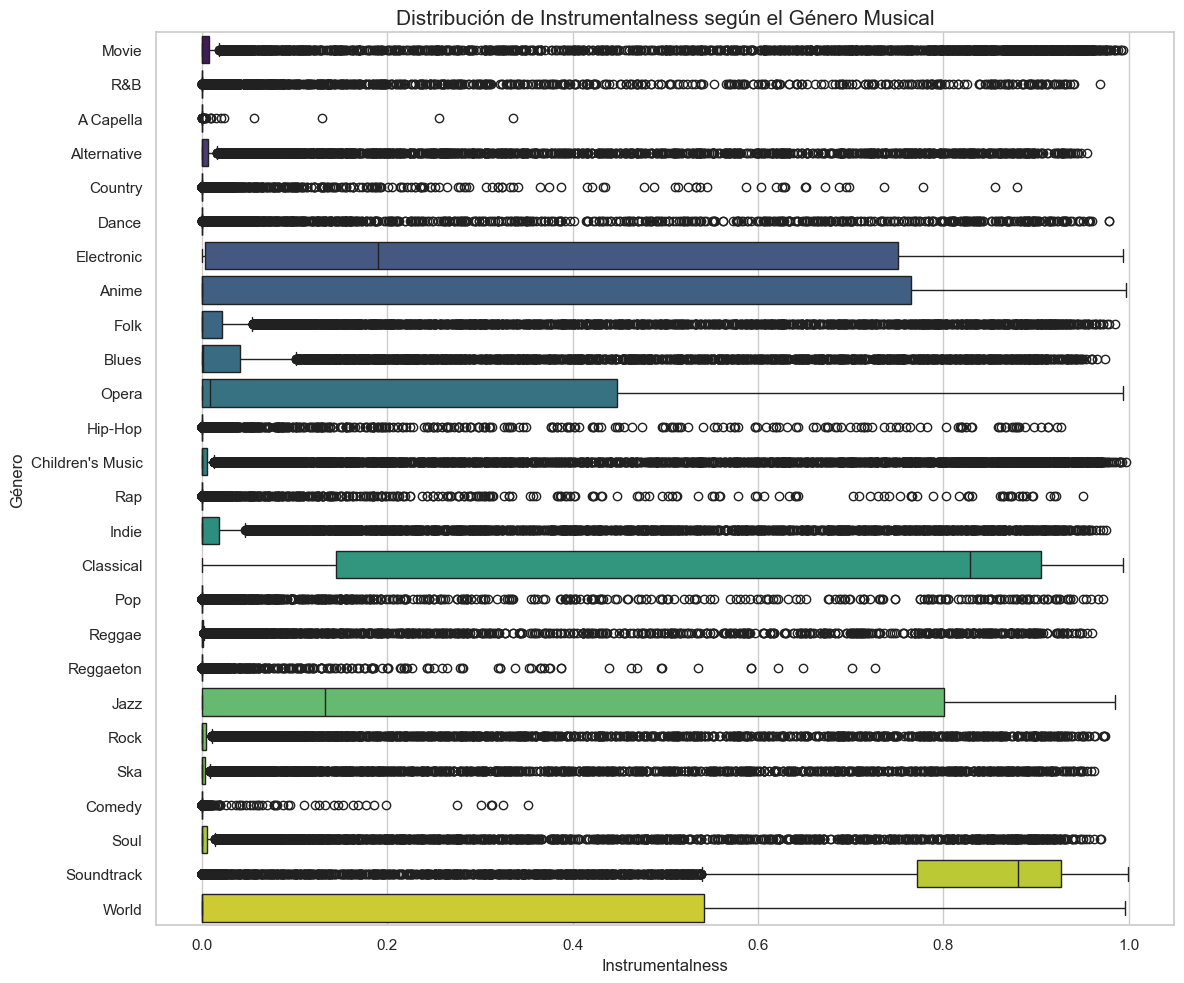

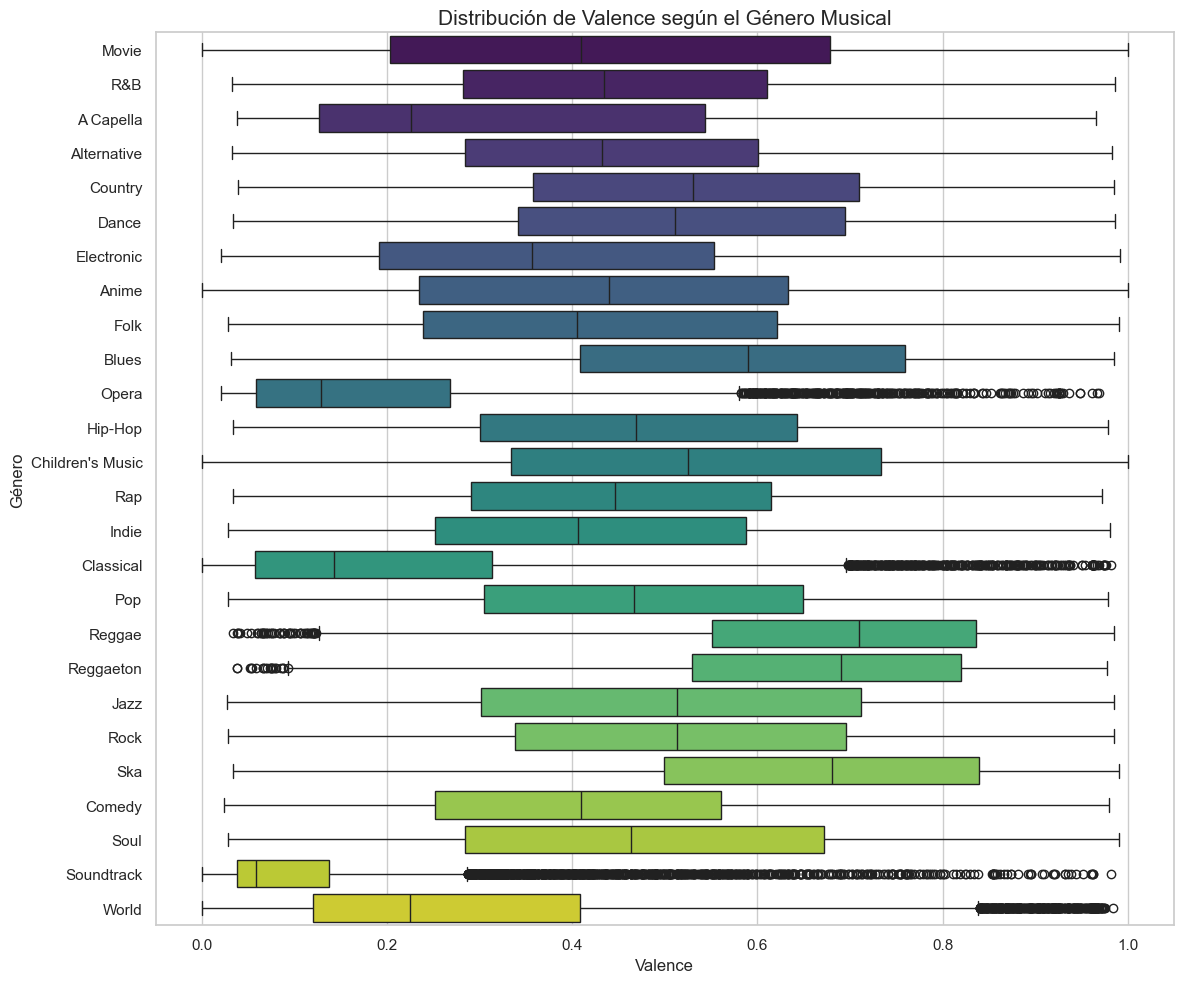

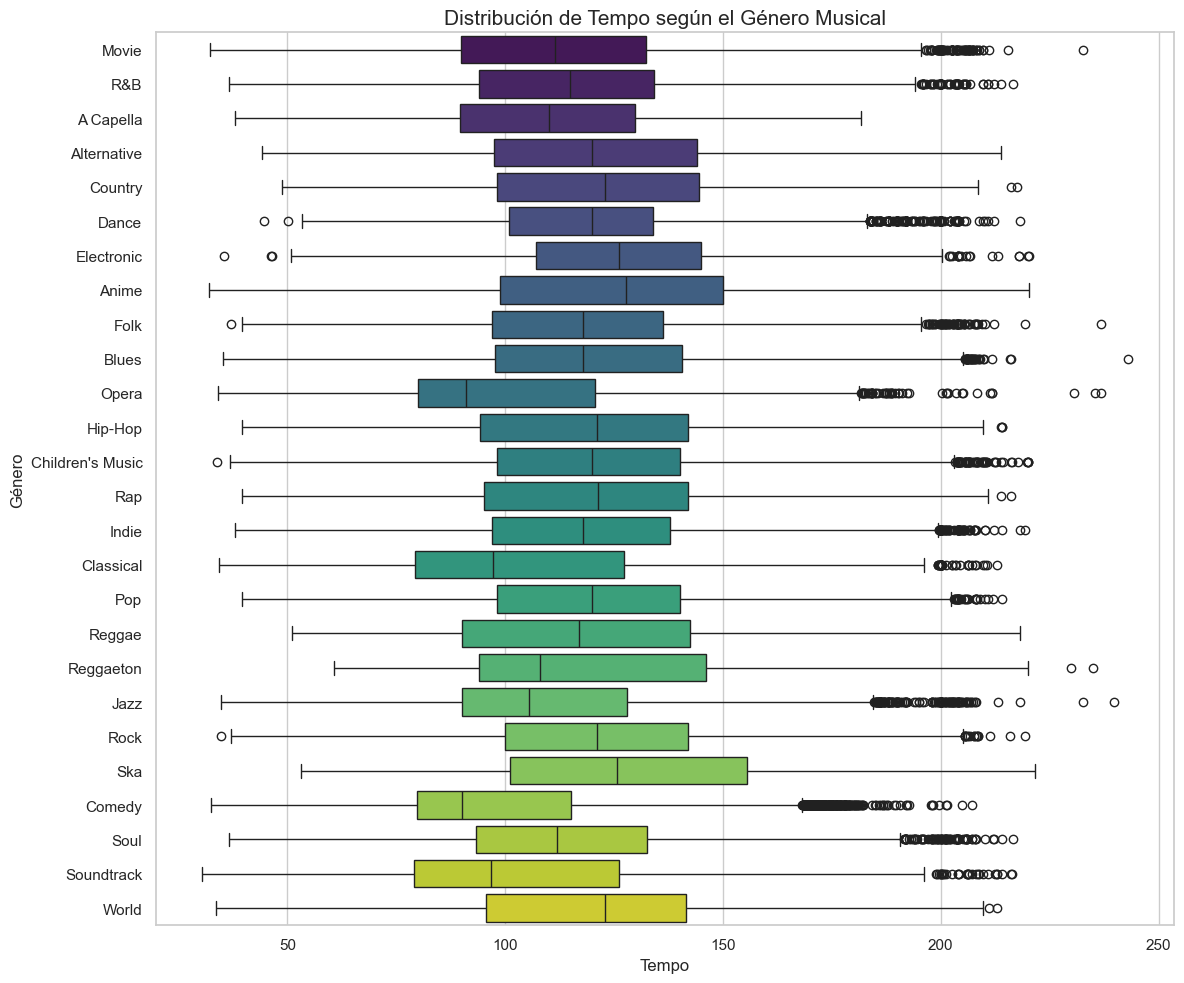

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de variables numéricas que queremos analizar
features = [
    'danceability', 'energy', 'loudness', 'speechiness', 
    'acousticness', 'instrumentalness', 'valence', 'tempo'
]

# Bucle para crear un gráfico por cada característica
for feature in features:
    plt.figure(figsize=(12, 10))
    # Usamos diferentes paletas para variar visualmente
    sns.boxplot(data=df, x=feature, y='genre', palette='viridis')
    
    plt.title(f'Distribución de {feature.capitalize()} según el Género Musical', fontsize=15)
    plt.xlabel(feature.capitalize(), fontsize=12)
    plt.ylabel('Género', fontsize=12)
    plt.tight_layout()
    plt.show()

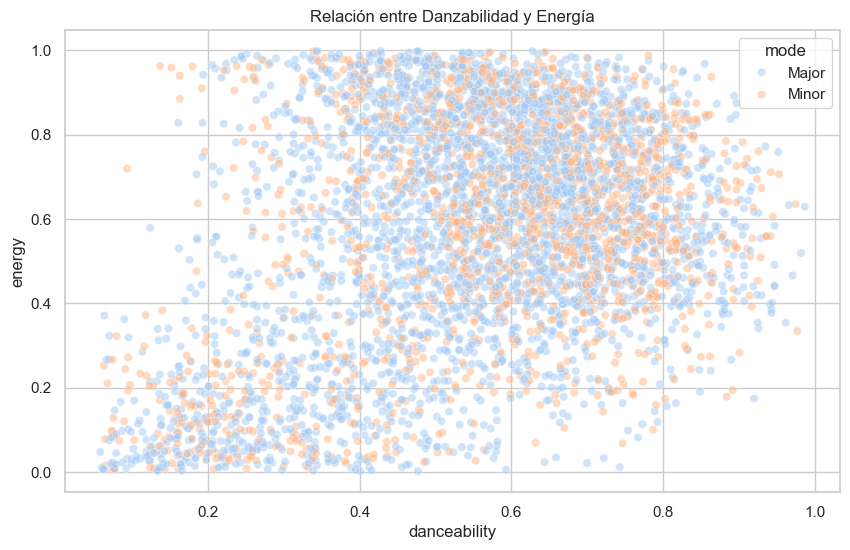

In [26]:

sample_df = df.sample(5000)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df, x='danceability', y='energy', hue='mode', alpha=0.5)
plt.title('Relación entre Danzabilidad y Energía')
plt.show()

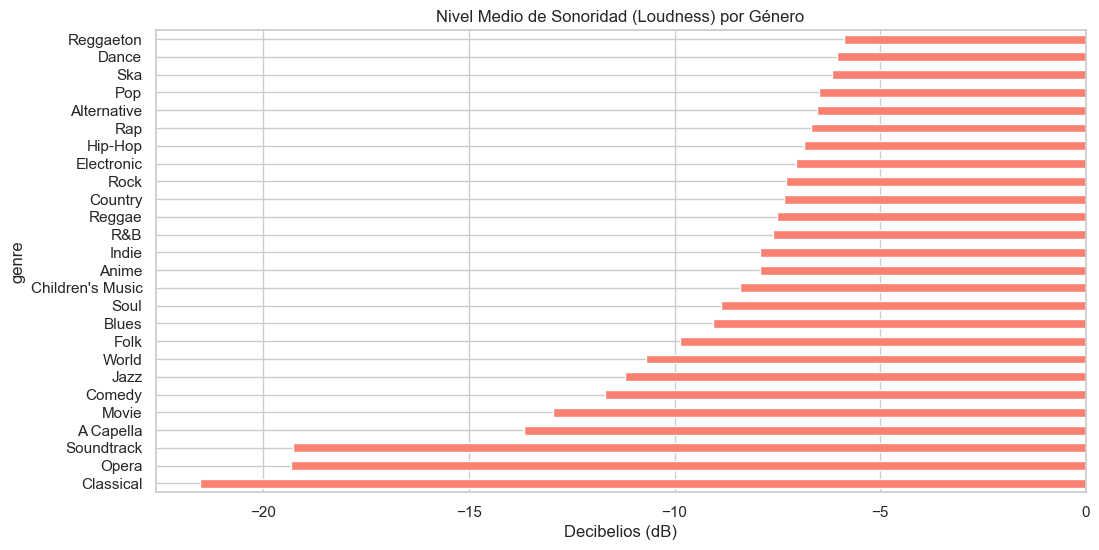

In [29]:
plt.figure(figsize=(12, 6))
df.groupby('genre')['loudness'].mean().sort_values().plot(kind='barh', color='salmon')
plt.title('Nivel Medio de Sonoridad (Loudness) por Género')
plt.xlabel('Decibelios (dB)')
plt.show()

In [32]:

df_zero_signature = df[df['time_signature'] == '0/4']

df_zero_signature

,genre,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
14520,Dance,60,0.184,0.619,257560,0.539000,0.000000,C,0.2880,-6.900,Major,0.3870,145.618,0/4,0.4240
59106,Opera,14,0.869,0.193,395293,0.107000,0.857000,C,0.1170,-20.963,Minor,0.0462,119.472,0/4,0.0377
80544,Opera,12,0.966,0.255,90560,0.045600,0.019000,C#,0.0613,-28.187,Major,0.0523,141.904,0/4,0.0349
82665,Opera,12,0.973,0.301,197333,0.105000,0.000019,D,0.0838,-16.219,Major,0.0400,99.886,0/4,0.2470
111059,Pop,61,0.184,0.619,257560,0.539000,0.000000,C,0.2880,-6.900,Major,0.3870,145.618,0/4,0.4240
115895,Rap,61,0.184,0.619,257560,0.539000,0.000000,C,0.2880,-6.900,Major,0.3870,145.618,0/4,0.4240
167567,Comedy,41,0.942,0.440,290123,0.532000,0.000000,F,0.9060,-20.569,Major,0.9440,83.029,0/4,0.0672
208898,World,41,0.977,0.338,205187,0.000982,0.239000,G#,0.0966,-28.820,Major,0.0465,93.066,0/4,0.0776


In [33]:
df = df[df['time_signature'] != '0/4']

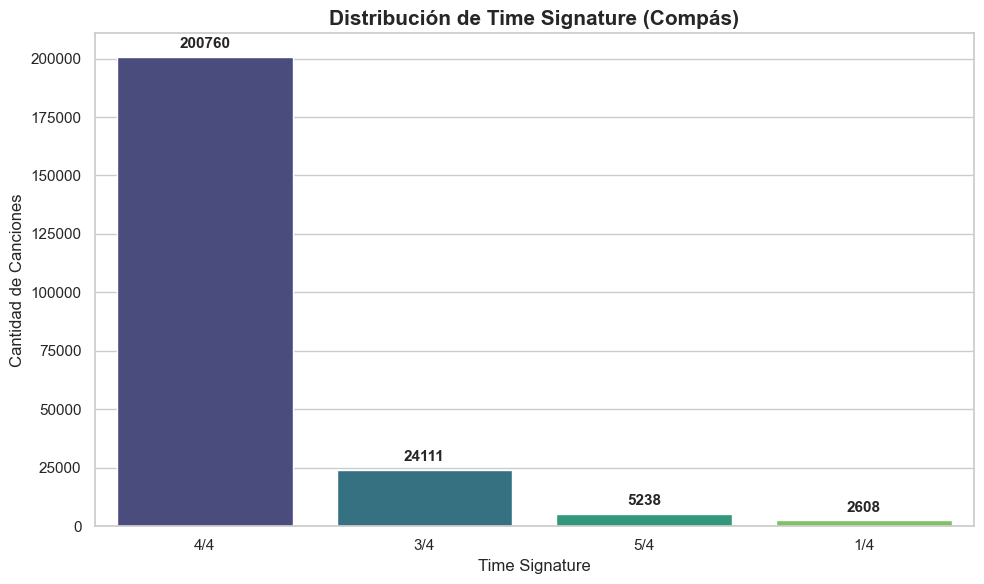

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))


ax = sns.countplot(
    data=df, 
    x='time_signature', 
    palette='viridis', 
    order=df['time_signature'].value_counts().index
)

# Añadir títulos y etiquetas
plt.title('Distribución de Time Signature (Compás)', fontsize=15, weight='bold')
plt.xlabel('Time Signature', fontsize=12)
plt.ylabel('Cantidad de Canciones', fontsize=12)


for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

In [36]:
!pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.4/101.7 MB 19.5 MB/s eta 0:00:06
   -- ------------------------------------- 7.3/101.7 MB 19.0 MB/s eta 0:00:05
   ---- ----------------------------------- 11.3/101.7 MB 19.2 MB/s eta 0:00:05
   ----- ---------------------------------- 14.7/101.7 MB 19.2 MB/s eta 0:00:05
   ------- -------------------------------- 19.1/101.7 MB 18.7 MB/s eta 0:00:05
   -------- ------------------------------- 22.5/101.7 MB 18.5 MB/s eta 0:00:05
   ---------- ----------------------------- 26.7/101.7 MB 18.5 MB/s eta 0:00:05
   ------------ --------------------------- 30.7/101.7 MB 18.5 MB/s eta 0:00:04
   ------------- -------------------------- 34.3/101.7 MB 18.5 MB/s eta 0:00:04
   --------------- ------------------------ 38.3/101.7 MB 18.4 MB/s eta 0:00:04
   ---------------- ----------------------- 42.2/101.7 MB 18.4 MB/s eta 0:00:04
   ------------------ --------------------- 46.4/10

In [24]:
import sys
import os
import importlib

sys.path.append(os.path.abspath(".."))

import src.models.train_model as tm
importlib.reload(tm)

<module 'src.models.train_model' from '/Users/juanpabloparrado/proyecto-ml/src/models/train_model.py'>

In [26]:
from src.models.train_model import train_models
results = train_models(X, y)

Entrenando Logistic Regression...
Entrenando Random Forest...
Entrenando Gradient Boosting...
Entrenando KNN...


In [27]:
import pandas as pd

summary = []

for model_name, result in results.items():
    report = result["report"]
    summary.append({
        "Modelo": model_name,
        "Accuracy": report["accuracy"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    })

summary_df = pd.DataFrame(summary).sort_values(by="Weighted F1", ascending=False)
summary_df

,Modelo,Accuracy,Macro F1,Weighted F1
2,Gradient Boosting,0.602961,0.550118,0.588261
1,Random Forest,0.567074,0.534665,0.559918
3,KNN,0.510957,0.471370,0.506450
0,Logistic Regression,0.523764,0.429992,0.490769


In [10]:
import importlib
import src.features.preprocessing as prep

importlib.reload(prep)

from src.features.preprocessing import (
    clean_columns,
    apply_genre_grouping,
    remove_unwanted_classes,
    split_features_target
)

In [29]:
df = pd.read_csv("../data/raw/SpotifyFeatures.csv")

df = clean_columns(df)
df = apply_genre_grouping(df)
df = remove_unwanted_classes(df)

X, y = split_features_target(df)

print(y.value_counts())

genre_grouped
mainstream      64246
soundtrack      26388
hiphop          18527
jazz_blues      18464
folk_country    17963
reggae          17645
classical       17536
kids            14756
electronic       9377
world            9096
latin            8927
Name: count, dtype: int64


# Nuevos mdodelos con 4 variables

In [30]:
import importlib
import src.features.preprocessing_4classes as prep4

importlib.reload(prep4)

from src.features.preprocessing_4classes import (
    clean_columns,
    apply_genre_grouping_4,
    remove_unwanted_classes_4,
    split_features_target_4
)

In [31]:
df4 = pd.read_csv("../data/raw/SpotifyFeatures.csv")

df4 = clean_columns(df4)
df4 = apply_genre_grouping_4(df4)
df4 = remove_unwanted_classes_4(df4)

X4, y4 = split_features_target_4(df4)

print(y4.value_counts())

genre_grouped_4
other         69417
mainstream    64246
acoustic      53963
urban         45099
Name: count, dtype: int64


In [32]:
results_4 = train_models(X4, y4)

Entrenando Logistic Regression...
Entrenando Random Forest...
Entrenando Gradient Boosting...
Entrenando KNN...


In [33]:
summary_4 = []

for model_name, result in results_4.items():
    report = result["report"]
    summary_4.append({
        "Modelo": model_name,
        "Accuracy": report["accuracy"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    })

summary_4_df = pd.DataFrame(summary_4).sort_values(by="Weighted F1", ascending=False)
summary_4_df

,Modelo,Accuracy,Macro F1,Weighted F1
2,Gradient Boosting,0.663315,0.659727,0.663711
1,Random Forest,0.645204,0.645957,0.646473
3,KNN,0.608035,0.605349,0.610069
0,Logistic Regression,0.579482,0.567410,0.576147
